## Importing libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


## Loading Data

In [2]:
train = pd.read_csv("train (1).csv")
test = pd.read_csv("test (1) (1).csv")



Data Structure

Train dataset

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  str    
 1   Date of Joining       22750 non-null  str    
 2   Gender                22750 non-null  str    
 3   Company Type          22750 non-null  str    
 4   WFH Setup Available   22750 non-null  str    
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), str(5)
memory usage: 2.6 MB


In [4]:
train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [12]:
train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


Test dataset

In [9]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           12250 non-null  str    
 1   Date of Joining       12250 non-null  str    
 2   Gender                12250 non-null  str    
 3   Company Type          12250 non-null  str    
 4   WFH Setup Available   12250 non-null  str    
 5   Designation           12250 non-null  float64
 6   Resource Allocation   12250 non-null  float64
 7   Mental Fatigue Score  12250 non-null  float64
dtypes: float64(3), str(5)
memory usage: 1.3 MB


In [8]:
test.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score
0,fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7
1,fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2
2,fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9
3,fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6
4,fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4


In [11]:
test.describe()

,Designation,Resource Allocation,Mental Fatigue Score
count,12250.000000,12250.000000,12250.000000
mean,2.175265,4.458857,5.720571
std,1.132885,2.045602,1.914063
min,0.000000,1.000000,0.000000
25%,1.000000,3.000000,4.500000
50%,2.000000,4.000000,5.900000
75%,3.000000,6.000000,7.100000
max,5.000000,10.000000,10.000000


## Data Cleaning

Missing Values

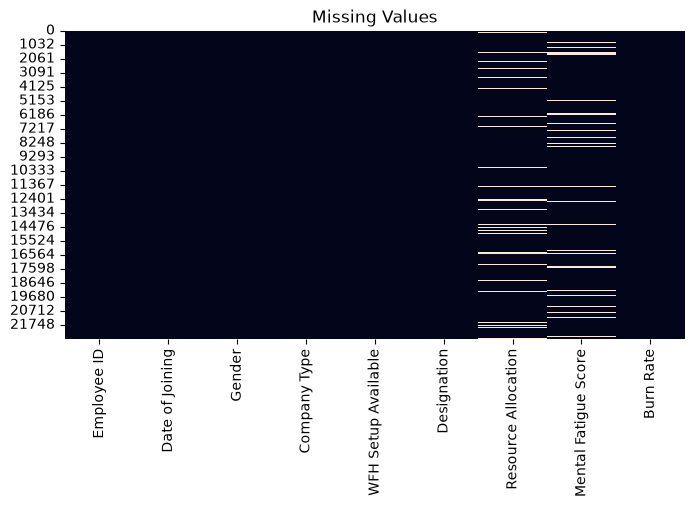

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [14]:
train.isnull().sum().sort_values(ascending=False)

Mental Fatigue Score    2117
Resource Allocation     1381
Burn Rate               1124
Employee ID                0
Date of Joining            0
WFH Setup Available        0
Company Type               0
Gender                     0
Designation                0
dtype: int64

In [15]:
test.isnull().sum().sort_values(ascending=False)

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
dtype: int64

Fixing missing values


In [ ]:
# drop rows with missing target values
train = train.dropna(subset=['Burn Rate'])


In [19]:
# Fill missing values for numerical features with median
test['Mental Fatigue Score'] = test['Mental Fatigue Score'].fillna(train['Mental Fatigue Score'].median() )

test['Resource Allocation'] = test['Resource Allocation'].fillna(train['Resource Allocation'].median())

In [20]:
# Convert 'Date of Joining' to datetime format
train['Date of Joining'] = pd.to_datetime(train['Date of Joining'])
test['Date of Joining'] = pd.to_datetime(test['Date of Joining'])

In [21]:
for df in [train, test]:

    df['Joining_Month'] = df['Date of Joining'].dt.month
    df['Joining_Day'] = df['Date of Joining'].dt.day
    df['Joining_Quarter'] = df['Date of Joining'].dt.quarter

    df.drop('Date of Joining', axis=1, inplace=True)

In [ ]:
# dropping Employee ID column as it is not useful for prediction
train.drop('Employee ID', axis=1, inplace=True)
test.drop('Employee ID', axis=1, inplace=True)

## Exploratory Data Analysis

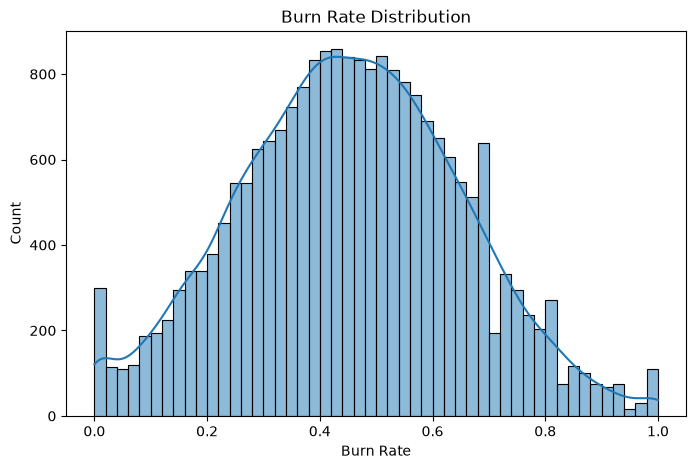

In [22]:
## Burn Rate Distribution

plt.figure(figsize=(8,5))
sns.histplot(train['Burn Rate'], kde=True)
plt.title("Burn Rate Distribution")
plt.show()


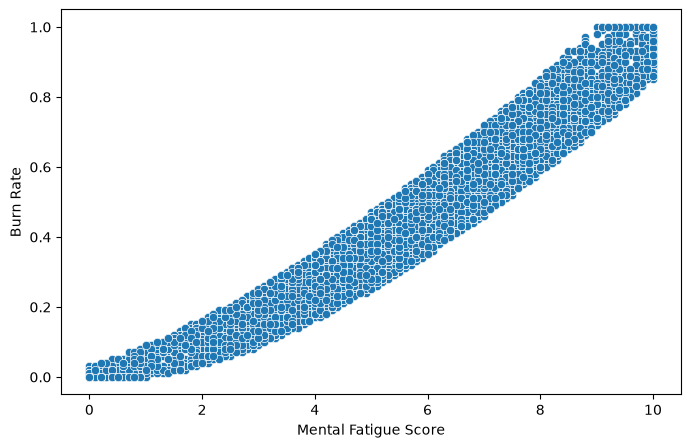

In [23]:
# Mental Fatigue vs Burn Rate

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=train,
    x='Mental Fatigue Score',
    y='Burn Rate'
)
plt.show()


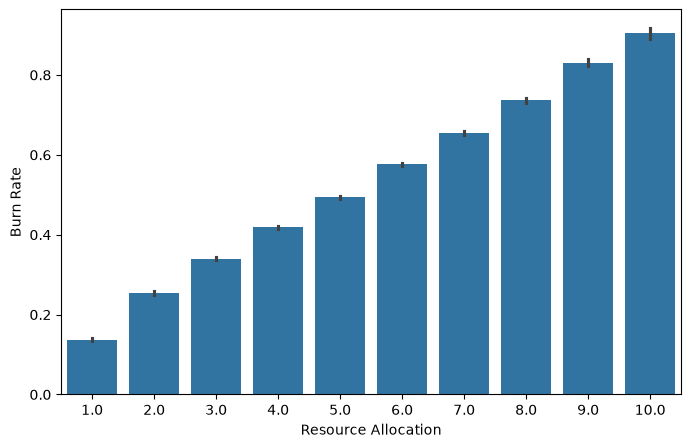

In [48]:
# Resource Allocation vs Burn Rate

plt.figure(figsize=(8,5))
sns.barplot(
    x='Resource Allocation',
    y='Burn Rate',
    data=train
)
plt.show()

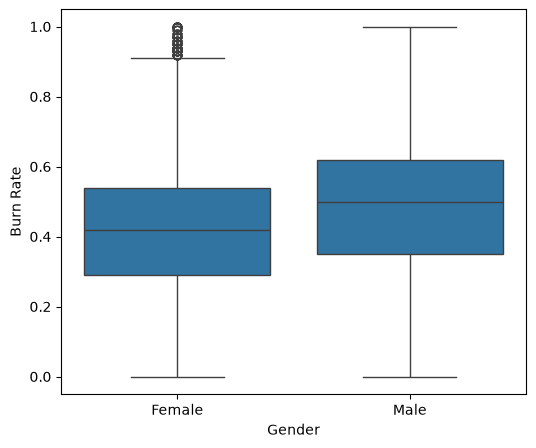

In [25]:
# Gender vs Burn Rate

plt.figure(figsize=(6,5))
sns.boxplot(
    x='Gender',
    y='Burn Rate',
    data=train
)
plt.show()

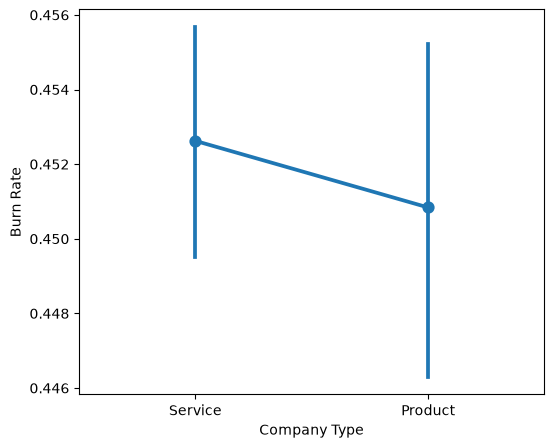

In [47]:
# Company type vs Burn Rate

plt.figure(figsize=(6,5))
sns.pointplot(
    x='Company Type',
    y='Burn Rate',
    data=train
)
plt.show()

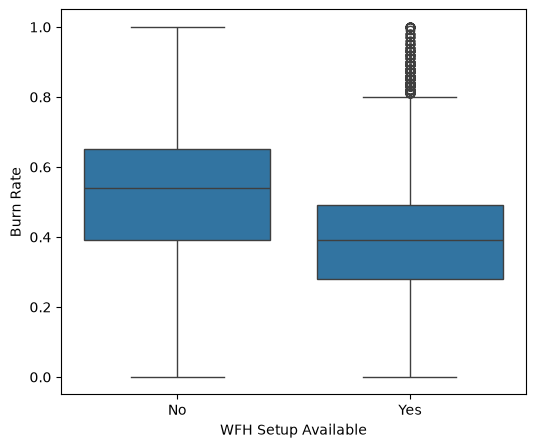

In [27]:
# WFH Setup vs Burn Rate

plt.figure(figsize=(6,5))
sns.boxplot(
    x='WFH Setup Available',
    y='Burn Rate',
    data=train
)
plt.show()

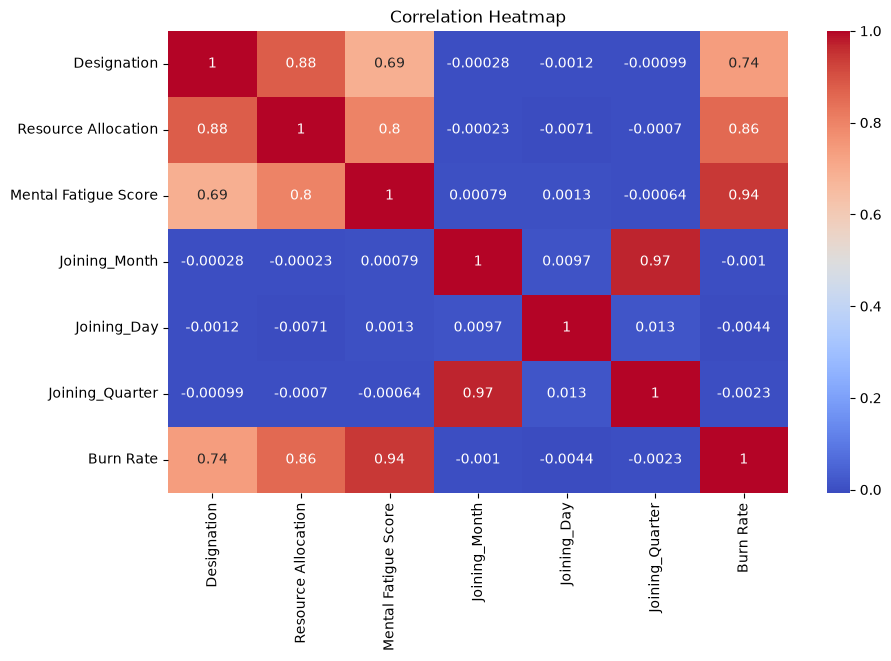

In [28]:
# Correlation Analysis

num_cols = [
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score',
    'Joining_Month',
    'Joining_Day',
    'Joining_Quarter',
    'Burn Rate'
]

corr = train[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


## Feature Engineering

In [29]:
X = train.drop('Burn Rate', axis=1)
y = train['Burn Rate']


In [31]:
# Define categorical and numerical features

categorical_features = [
    'Gender',
    'Company Type',
    'WFH Setup Available'
]

numerical_features = [
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score',
    'Joining_Month',
    'Joining_Day',
    'Joining_Quarter'
]

## Train Validation Split

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Preprocessing Pipeline



In [ ]:
# Creating Preprocessing Pipelines
numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Model 

 Baseline Model

In [ ]:
# creating a pipeline that combines preprocessing and model training
# baseline model using linear regression
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

preds = linear_model.predict(X_val)

In [34]:
# evaluate the model

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
r2 = r2_score(y_val, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.053487694564748965
RMSE: 0.07093723293131074
R2: 0.8678839480553959


Random Forest Model

In [35]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_val)


In [36]:
# Evaluate the Random Forest model

mae = mean_absolute_error(y_val, rf_preds)
rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
r2 = r2_score(y_val, rf_preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.047357112133829316
RMSE: 0.060544124817329056
R2: 0.9037609979587679


XGBoost Model

In [38]:
xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_val)

In [39]:
# Evaluate the XGBoost model

mae = mean_absolute_error(y_val, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
r2 = r2_score(y_val, xgb_preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.04779935773779522
RMSE: 0.06099445236344028
R2: 0.9023240211456011


## Training Final Model on Full Dataset

In [41]:
final_model = xgb_model

final_model.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Employee ID','Gender','Company Type',...,'Joining_Month','Joining_Day', 'Joining_Quarter']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. T

## Test Set Prediction

In [42]:
test_predictions = final_model.predict(test)


# Submission

In [44]:
submission = pd.read_csv("test (1) (1).csv")

submission['Burn Rate'] = test_predictions

submission = submission[
    ['Employee ID', 'Burn Rate']
]

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()


,Employee ID,Burn Rate
0,fffe31003300390039003000,0.615983
1,fffe31003300310037003800,0.363616
2,fffe33003400380035003900,0.370049
3,fffe3100370039003200,0.393907
4,fffe32003600390036003700,0.531105
